## Importing Modules

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Data Import

In [3]:
data = pd.read_csv("CarPrice_Assignment.csv")

## Analyze The Data

In [10]:
print(data.head())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [5]:
print(data.shape)

(205, 26)


In [7]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [8]:
print(data.isnull().sum())

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


In [11]:
print("Duplicate Rows:", data.duplicated().sum())

data = data.drop_duplicates()

Duplicate Rows: 0


## Feature Engineering

In [12]:
data["brand"] = data["CarName"].str.split().str[0].str.lower()

brand_mapping = {
    "maxda": "mazda",
    "porcshce": "porsche",
    "toyouta": "toyota",
    "vokswagen": "volkswagen",
    "vw": "volkswagen"
}

data["brand"] = data["brand"].replace(brand_mapping)

data.drop(["car_ID", "CarName"], axis=1, inplace=True)

## Data Encoding


In [13]:
data["fueltype"] = data["fueltype"].map({
    "diesel": 1,
    "gas": 0
})

data["aspiration"] = data["aspiration"].map({
    "turbo": 1,
    "std": 0
})

data["doornumber"] = data["doornumber"].map({
    "four": 1,
    "two": 0
})

data["enginelocation"] = data["enginelocation"].map({
    "front": 1,
    "rear": 0
})

## One Hot Encoding

In [15]:
data = pd.get_dummies(
    data,
    columns=[
        "brand",
        "carbody",
        "drivewheel",
        "enginetype",
        "cylindernumber",
        "fuelsystem"
    ],
    drop_first=True,
    dtype=int
)


In [16]:
print("Total Missing Values:", data.isnull().sum().sum())


Total Missing Values: 0


## Dividing Values Into Input And Output

In [18]:
X = data.drop("price", axis=1)
y = data["price"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (205, 64)
y Shape: (205,)


## Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,random_state=42
)

In [20]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (164, 64)
X_test: (41, 64)
y_train: (164,)
y_test: (41,)


## Creating Model

In [22]:

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Predicted Values

In [24]:
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[29778.5170846  21742.73235495 11134.24819083 12506.64100721
 30073.8111985   6788.18571244  7677.1953874   7230.80555871
  9508.13260147  7862.71015641]


## Evalution Metrices

In [37]:
n = X_train.shape[0]  # n = 164
p = X_train.shape[1]  # p = 64

adjusted_r2 = 1 - ((1 - r2_train) * (n - 1) / (n - p - 1))


print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Adjusted R2 Score:", adjusted_r2)

MAE: 1763.5659861999238
MSE: 7128546.783600786
RMSE: 2669.93385378754
R2 Score: 0.9097012452093421
Adjusted R2 Score: 0.958350921732291


In [33]:
# Underfit And Overfit
# R Squared  Training Is Low & R Squared  Testing Is Low  --- Underfit
# R Squared  Training Is High & R Squared  Testing Is Low  --- Overfit

y_train_pred= model.predict(X_train)
r2_train = r2_score(y_train , y_train_pred)
print(f"Trainning Data R2 {r2_train}")
print(f"Testing Data R2 {r2}")

Trainning Data R2 0.9747039340582626
Testing Data R2 0.9097012452093421


## Comparasion B/W Actual And Predicted Values

In [27]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(comparison.head(10))

   Actual Price  Predicted Price
0     30760.000     29778.517085
1     17859.167     21742.732355
2      9549.000     11134.248191
3     11850.000     12506.641007
4     28248.000     30073.811199
5      7799.000      6788.185712
6      7788.000      7677.195387
7      9258.000      7230.805559
8     10198.000      9508.132601
9      7775.000      7862.710156


## Visualize

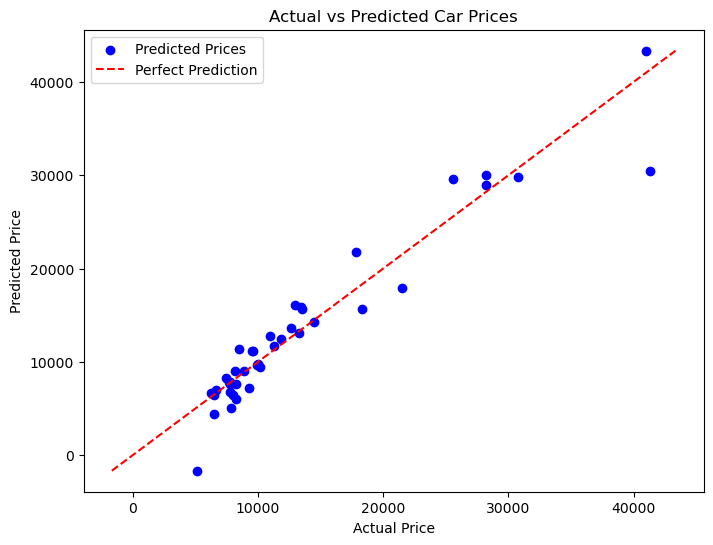

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, color="blue", label="Predicted Prices")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.legend()
plt.show()